# GeoPandas

GeoPandas extends the pandas library to support geospatial data, allowing you to read, write, analyze, and visualize geographic datasets using familiar DataFrame operations. This module introduces the core concepts and workflows you will use throughout the course.

**Topics covered in this module:**
- Reading geospatial files into GeoDataFrames
- Exploring geometries and computing geometric properties (area, length)
- Writing data to different file formats (GeoPackage, Shapefile, FlatGeobuf)
- Supported file formats and I/O engines
- Creating GeoDataFrames from scratch (coordinates and CSV files)
- Setting and understanding coordinate reference systems (CRS)

## Learning Objectives

At the end of this module, you should be able to:
- Read geospatial data from files into GeoDataFrames using `gpd.read_file()`
- Explore GeoDataFrame properties: geometry types, column names, and CRS
- Compute geometric properties such as area and create derived columns
- Write GeoDataFrames to common file formats using `.to_file()`
- Create GeoDataFrames from scratch using coordinate tuples and shapely geometries
- Convert tabular data (CSV with coordinates) into geospatial GeoDataFrames using `gpd.points_from_xy()`
- Assign a coordinate reference system using `.set_crs()`

## Data structures in geopandas

In this module, we will cover the basics of geopandas, a Python library to interact with geospatial vector data.

Geopandas provides an easy-to-use interface to vector data sets. It combines the capabilities of `pandas` with the geometry handling functionality of `shapely`, the geo-spatial file format support of `fiona` (for Geopandas versions <1.0) and `pyogrio` (version 1.0 and later), and the map projection libraries of `pyproj`. It extends the data types used by `pandas` to allow geospatial operations. 

In the next sections, we will introduce the basic data structures in geopandas: `GeoSeries` and `GeoDataFrame`. 

## What is a GeoDataFrame?

A GeoDataFrame is basically like a pandas.DataFrame that contains at least one dedicated column for storing geometries. The geometry column is a GeoSeries which contains the geometries as shapely objects (points, lines, polygons, multipolygons etc.). As we learned previously, shapely provides many useful attributes and methods to work with geometries. Luckily, these same functionalities can be directly applied to GeoSeries making it convenient to work with data layers that may contain thousands or even millions of geographic features. 

In this section, you will learn various useful techniques in geopandas that help you to work with geographic data in vector format.

![Figure](img/geodataframe.png)

_**Figure**. Geometry column in a GeoDataFrame._

## Reading a file

Like with pandas, a typical first step when starting to work with geopandas is to read data from a given file. In geopandas, we can use a generic function `.read_file()` for reading geospatial data from various data formats. The data folder contains census data from Lake County, Illinois which we will use to introduce the basic data input/output functionalities of geopandas. 

We will first import geopandas as **gpd**. Then we will read the file by passing the filepath to .read_file() function:

In [1]:
import geopandas as gpd

data = gpd.read_file('data/LakeCounty.gpkg')

You can use the .read_file() command in this way to read data from many different vector formats (GeoPackage, Shapefile, GeoJSON, etc.). Let's take a look at the data type:

In [2]:
type(data)

geopandas.geodataframe.GeoDataFrame

Here we see that the **data** variable is a `GeoDataFrame` which extends the functionalities of a DataFrame to handle spatial data. We can apply many familiar pandas methods to explore the contents of our GeoDataFrame. Let's have a look at the first rows of the data: 

In [3]:
data.head(5)

,ZIP,Total_Pop,geometry
0,60002,24305.0,"MULTIPOLYGON (((1087210.141 2123068.712, 10844..."
1,60010,44416.0,"MULTIPOLYGON (((1043125.987 2030393.498, 10427..."
2,60015,27373.0,"MULTIPOLYGON (((1114634.056 2017318.644, 11143..."
3,60020,10246.0,"MULTIPOLYGON (((1030794.477 2094083.825, 10304..."
4,60030,36563.0,"MULTIPOLYGON (((1074365.439 2074754.258, 10741..."


We can see that there are three columns. **ZIP** and **Total_Pop** represent attribute information, namely the number of people living on each census tract and a unique zip code for the tract. The column **geometry** contains the geographic data (polygons) for each census tract.

It is always a good idea to explore your geographic data on a map. Creating a simple map from a geodataframe is really easy. You can use the `.plot()` method bundled in the GeoDataFrame instance to create a map based on the geometries of the data. Under the hood, geopandas uses matplotlib for plotting. Let's do a quick visualization of our data:

<Axes: >

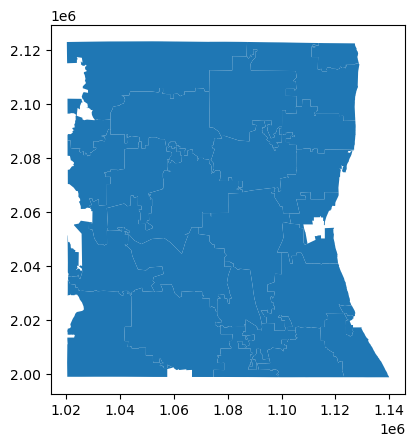

In [4]:
data.plot()

_**Figure**. Census tract polygons for Lake County, Illinois._

Here is our first map with geopandas! This map gives a quick overview of the geometries of the census tracts. The `x` and `y` axes are based on coordinate values of the geometries, in this case represented as meters.

#### Quiz

Based on your knowledge of pandas DataFrame, use proper GeoDataFrame methods to find the following information:

- Number of rows in the data?
- Number of unique census tracts (based on column **ZIP**)?
- Total population (based on column **Total_Pop**)?

In [ ]:
# Solution


number of rows: 27
number of unique census tracts: 27
Total population: 723040.0


## Geometries in geopandas

By default, geopandas looks for the geometries from an attribute called `.geometry`, which is ultimately a `GeoSeries` data structure containing `shapely` geometric objects. In practice, the `.geometry` attribute links to a specific column in the GeoDataFrame. By default the geometries are stored into column named "geometry", when you read in a spatial file. However, a geodataframe can have multiple columns containing geometries, and you can change which column should be considered as the "active geometry". 

Let's have a closer look at the `.geometry` attribute of our data:

In [6]:
data.geometry.head()

0    MULTIPOLYGON (((1087210.141 2123068.712, 10844...
1    MULTIPOLYGON (((1043125.987 2030393.498, 10427...
2    MULTIPOLYGON (((1114634.056 2017318.644, 11143...
3    MULTIPOLYGON (((1030794.477 2094083.825, 10304...
4    MULTIPOLYGON (((1074365.439 2074754.258, 10741...
Name: geometry, dtype: geometry

In [7]:
type(data.geometry)

geopandas.geoseries.GeoSeries

As we can see here,  the geometry attribute contains polygon geometries stored in a GeoSeries data structure. The last output line of the .head() command reveals that the data type (dtype) of this column is `geometry`, i.e. geometries have their own data type. As we learned earlier, the `shapely.geometry` objects have various useful attributes and methods that we can use to work with geographic data. It is possible to use these `shapely` methods directly in geopandas and apply them to a whole `GeoSeries`. 

With this in mind, let's proceed and extract information about the area of each census tract polygon. Extracting the area for all geometries in our data can be done easily by calling the attribute `.area`. As a reminder, the census data are in a metric coordinate reference system, so the area values will be given in square meters:

In [8]:
data.geometry.area

0     1.149062e+09
1     8.027354e+08
2     3.674576e+08
3     1.666177e+08
4     8.455179e+08
5     5.271176e+08
6     3.457929e+08
7     1.780943e+07
8     4.517757e+07
9     2.127777e+08
10    6.214754e+08
11    7.304244e+08
12    9.193818e+08
13    8.190083e+08
14    6.175913e+08
15    2.574212e+08
16    1.399011e+08
17    1.700669e+08
18    5.196587e+08
19    7.282379e+08
20    5.051635e+08
21    3.919074e+08
22    3.898800e+08
23    2.277724e+08
24    1.413737e+08
25    6.262642e+08
26    3.919550e+08
dtype: float64

The same result can be achieved by using the syntax `data.area`. Let's convert the area values from square meters to square kilometers and store them into a new column called `area_km2`:

In [9]:
data["area_km2"] = data.area / 1000000
data.head()

,ZIP,Total_Pop,geometry,area_km2
0,60002,24305.0,"MULTIPOLYGON (((1087210.141 2123068.712, 10844...",1149.062138
1,60010,44416.0,"MULTIPOLYGON (((1043125.987 2030393.498, 10427...",802.735363
2,60015,27373.0,"MULTIPOLYGON (((1114634.056 2017318.644, 11143...",367.457580
3,60020,10246.0,"MULTIPOLYGON (((1030794.477 2094083.825, 10304...",166.617676
4,60030,36563.0,"MULTIPOLYGON (((1074365.439 2074754.258, 10741...",845.517891


As we can see, now we added a new column into our GeoDataFrame which contains the area of each polygon as square kilometers. We can also visualize the data and make a choropleth map using the area to determine the color. To do this, we can use the parameter `column` of the `.plot()` method in geopandas to specify that the color for each polygon should be based on the values stored in the `area_km2` column:  

<Axes: >

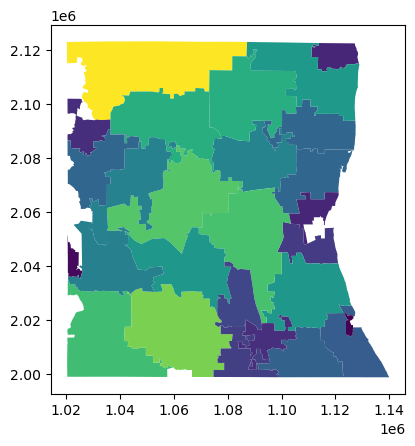

In [10]:
data.plot(column="area_km2")

_**Figure**. A map showing census tracts colored based on the size of the polygon._

#### Quiz

Create a new column `pop_density_km2` and populate it with population density values (population / km2) based on columns `Total_Pop` and `area_km2`. Find answers to the following questions:

- What was the average population density?
- What was the maximum population density for all census tracts?

In [ ]:
# Use this cell to enter your solution.



average pop density: 57.033105932556644
maximum pop density: 303.2100794243377


## Writing data into a file

In a similar way as reading data, writing the contents of your GeoDataFrame into a specific file is one of the most typical operations when working with geographic data. It is possible to export the GeoDataFrame into various data formats using the `.to_file()` method. Let's start by learning how we can write data into a GeoPackage. 

Before proceeding, let's see how the data looks like at this point:

Saving your processed data to a file is an important step in any analysis workflow. It allows you to share results, load them in other tools (e.g., QGIS), and avoid re-running processing steps.

In [13]:
data.head()

,ZIP,Total_Pop,geometry,area_km2,pop_density_km2
0,60002,24305.0,"MULTIPOLYGON (((1087210.141 2123068.712, 10844...",1149.062138,21.152033
1,60010,44416.0,"MULTIPOLYGON (((1043125.987 2030393.498, 10427...",802.735363,55.330813
2,60015,27373.0,"MULTIPOLYGON (((1114634.056 2017318.644, 11143...",367.457580,74.492952
3,60020,10246.0,"MULTIPOLYGON (((1030794.477 2094083.825, 10304...",166.617676,61.494076
4,60030,36563.0,"MULTIPOLYGON (((1074365.439 2074754.258, 10741...",845.517891,43.243319


Writing the contents of this GeoDataFrame into a file can be done using the `.to_file()` method. To use the method, we need to pass the filepath to the output file. For the most common geospatial file formats (e.g. GPKG, ESRI Shapefile, GeoJSON, GML, MapInfo File, FlatGeobuf), geopandas automatically identifies the correct file format based on the file extension in the file path. 

In the example below, the file extension of `.gpkg` at the end of `output_fp` is sufficient to determine that the GeoDataFrame should be written in GeoPackage format:

In [14]:
# Create a output path for the data
output_fp = "data/Lake_County_pop_density.gpkg"

# Write the file
data.to_file(output_fp)

Now we have successfully stored the data into a file called `Lake_County_pop_density.gpkg`. 

To be more explicit, you can use the `driver` parameter to specify the output file format, allowing you to write data into numerous data formats supported by `GDAL` which is used by `geopandas` under the hood for reading and writing data. 

As an input, you should give the name of the `driver` as a string (see the names from [GDAL documentation](https://gdal.org/drivers/vector/index.html)), such as `FlatGeobuf` which is used to write the data into a performant FlatgeoBuf file format that supports fast reading and writing of geospatial data:

In [15]:
# Write the file
output_fp = "data/Lake_County_pop_density.fgb"

data.to_file(output_fp, driver="FlatGeobuf")

You can also write the output to ESRI Shapefile format:

In [16]:
# Write the file
output_fp = "data/Lake_County_pop_density.shp"

data.to_file(output_fp, driver="ESRI Shapefile")

/var/folders/d6/gwgxc4k54kn3257svv59qtgh0000gp/T/ipykernel_21250/3067767773.py:4: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  data.to_file(output_fp, driver="ESRI Shapefile")


Whenever writing data, if you have an existing file with the same name, geopandas will automatically overwrite the contents without asking. Hence, it is good to be mindful about the naming of output files whenever writing data to disk. 

Some file formats also support appending to existing files. You can enable this functionality by using the `mode` parameter and specifying `mode='a'` which will add rows into an existing output file.


#### Quiz

Read the output file (`Lake_County_pop_density.shp`) using geopandas and print the first five rows.

In [ ]:
# Use this cell to enter your solution.


,ZIP,Total_Pop,area_km2,pop_densit,geometry
0,60002,24305.0,1149.062138,21.152033,"POLYGON ((1087210.141 2123068.712, 1087016.524..."
1,60010,44416.0,802.735363,55.330813,"POLYGON ((1043125.987 2030393.498, 1042782.981..."
2,60015,27373.0,367.457580,74.492952,"POLYGON ((1114634.056 2017318.644, 1114456.579..."
3,60020,10246.0,166.617676,61.494076,"POLYGON ((1030794.477 2094083.825, 1031716.470..."
4,60030,36563.0,845.517891,43.243319,"POLYGON ((1074365.439 2074754.258, 1074674.419..."


## Different file formats for reading and writing geographic data 

There exists numerous GIS data formats, such as [GeoPackage](https://en.wikipedia.org/wiki/GeoPackage), [GeoJSON](https://en.wikipedia.org/wiki/GeoJSON), [KML](https://en.wikipedia.org/wiki/Keyhole_Markup_Language), and [Shapefile](https://en.wikipedia.org/wiki/Shapefile). It is possible to read data from all these formats (plus many more) straight out of the box by geopandas. In the following, we will show some examples how to read and write data from different sources.

### Reading vector data

When we use the `.read_file()` function for reading data in various formats, geopandas actually uses a Python library under the hood to read the data (which again depends on `GDAL` software written mostly in C++ language).

For geopandas versions <1.0, geoPandas defaulted to use `fiona`. Starting from geoPandas version 1.0, the global default has changed from Fiona to `pyogrio`.

The main reason for this change is performance. pyogrio is optimized for the use case relevant for geoPandas: reading and writing in bulk. Because of this, in many cases speedups >5-20x can be observed.

You can explicitly change the io engine by:

In [18]:
import geopandas as gpd
gpd.options.io_engine = "fiona"


You can read and write all data formats that are supported by `fiona` or `pyogrio`. It is easy to find out all the data formats that are supported by default by calling `.list_drivers()`.


In [19]:
import fiona
fiona.supported_drivers

{'DXF': 'rw',
 'CSV': 'raw',
 'OpenFileGDB': 'raw',
 'ESRIJSON': 'r',
 'ESRI Shapefile': 'raw',
 'FlatGeobuf': 'raw',
 'GeoJSON': 'raw',
 'GeoJSONSeq': 'raw',
 'GPKG': 'raw',
 'GML': 'rw',
 'OGR_GMT': 'rw',
 'GPX': 'rw',
 'Idrisi': 'r',
 'MapInfo File': 'raw',
 'DGN': 'raw',
 'PCIDSK': 'raw',
 'OGR_PDS': 'r',
 'S57': 'r',
 'SQLite': 'raw',
 'TopoJSON': 'r'}

In [20]:
# If you see importing error, that means pyogrio is not installed on your computer
# To install the pyogrio package, open the Anaconda prompt, activate the pythongis environment, and run
# conda install -c conda-forge pyogrio
 
import pyogrio
pyogrio.list_drivers()

{'FITS': 'rw',
 'PCIDSK': 'rw',
 'netCDF': 'rw',
 'PDS4': 'rw',
 'VICAR': 'rw',
 'JP2OpenJPEG': 'r',
 'PDF': 'rw',
 'MBTiles': 'rw',
 'TileDB': 'rw',
 'BAG': 'rw',
 'EEDA': 'r',
 'OGCAPI': 'r',
 'ESRI Shapefile': 'rw',
 'MapInfo File': 'rw',
 'UK .NTF': 'r',
 'LVBAG': 'r',
 'OGR_SDTS': 'r',
 'S57': 'rw',
 'DGN': 'rw',
 'OGR_VRT': 'r',
 'Memory': 'rw',
 'CSV': 'rw',
 'NAS': 'r',
 'GML': 'rw',
 'GPX': 'rw',
 'LIBKML': 'rw',
 'KML': 'rw',
 'GeoJSON': 'rw',
 'GeoJSONSeq': 'rw',
 'ESRIJSON': 'r',
 'TopoJSON': 'r',
 'Interlis 1': 'rw',
 'Interlis 2': 'rw',
 'OGR_GMT': 'rw',
 'GPKG': 'rw',
 'SQLite': 'rw',
 'WAsP': 'rw',
 'PostgreSQL': 'rw',
 'OpenFileGDB': 'rw',
 'DXF': 'rw',
 'CAD': 'r',
 'FlatGeobuf': 'rw',
 'Geoconcept': 'rw',
 'GeoRSS': 'rw',
 'VFK': 'r',
 'PGDUMP': 'rw',
 'OSM': 'r',
 'GPSBabel': 'rw',
 'OGR_PDS': 'r',
 'WFS': 'r',
 'OAPIF': 'r',
 'EDIGEO': 'r',
 'SVG': 'r',
 'Idrisi': 'r',
 'XLS': 'r',
 'ODS': 'rw',
 'XLSX': 'r',
 'Elasticsearch': 'rw',
 'Carto': 'rw',
 'AmigoCloud': '

As we can see, by default there are close to 80 different file formats that are supported for reading data in pyogrio. In the list of supported drivers, 
- `r` is for file formats that pyogrio/geopandas has reading permission.
- `w` is for file formats it can write to.
- `a` marks formats for which pyogrio/geopandas can append new data to existing files. 

Let's read the same Lake County census data in a Shapefile format to see the basic syntax:

In [21]:
# Read Esri Shapefile
data = gpd.read_file('data/Lake_County_pop_density.shp')
data.head()

,ZIP,Total_Pop,area_km2,pop_densit,geometry
0,60002,24305.0,1149.062138,21.152033,"POLYGON ((1087210.141 2123068.712, 1087016.524..."
1,60010,44416.0,802.735363,55.330813,"POLYGON ((1043125.987 2030393.498, 1042782.981..."
2,60015,27373.0,367.457580,74.492952,"POLYGON ((1114634.056 2017318.644, 1114456.579..."
3,60020,10246.0,166.617676,61.494076,"POLYGON ((1030794.477 2094083.825, 1031716.470..."
4,60030,36563.0,845.517891,43.243319,"POLYGON ((1074365.439 2074754.258, 1074674.419..."


## Creating a GeoDataFrame from scratch

It is possible to create spatial data from scratch by using shapely's geometric objects. This makes it easy to convert, for example, a text file that contains coordinates into geospatial data layers. 

Let's create a simple GeoDataFrame based on coordinate information on the outlines of the H-STEM building. The coordinates represent the corners of the H-STEM building, which we can use to create a `Polygon` object. The order of the coordinates should always follow longitude-latitude order (i.e. `x` and `y` coordinates):

Sometimes your data does not come from a geospatial file -- you may have coordinates from a GPS, a list of building corners, or boundaries you want to define manually. In these cases, you need to create a GeoDataFrame from scratch.

In [22]:
from shapely.geometry import Polygon

coordinates = [
    (-88.54849,  47.120082),
    (-88.54757,  47.119911),
    (-88.54790,  47.119172),
    (-88.54884,  47.119341),
]

poly = Polygon(coordinates)

Now we can use this polygon to create a GeoDataFrame with geopandas. The data can be passed in as a list-like object. In this example, we have only one row and one column. We can pass the polygon inside a list, and specify that this data is stored into a column called `geometry`, so that geopandas will use the contents of that column as geometries.

In [23]:
gdf = gpd.GeoDataFrame(geometry=[poly])
gdf

,geometry
0,"POLYGON ((-88.54849 47.12008, -88.54757 47.119..."


<Axes: >

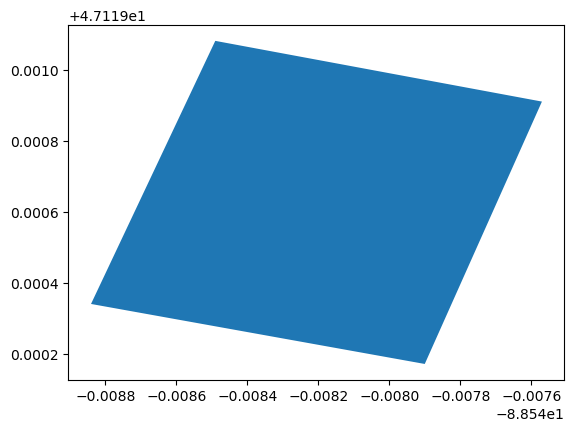

In [24]:
gdf.plot()

In this way, we have created a GeoDataFrame without any attributes. However, quite often you want to attach attribute information along with your geometry. 

We can create a GeoDataFrame from scratch with multiple attributes by passing a Python dictionary into the GeoDataFrame object as follows:

In [25]:
gdf_data = {
    "geometry": [poly],
    "name": "H-STEM Complex",
    "city": "Houghton",
    "state": 'Michigan',
    "year": 2024,
}
gdf = gpd.GeoDataFrame(data = gdf_data)
gdf

,geometry,name,city,state,year
0,"POLYGON ((-88.54849 47.12008, -88.54757 47.119...",H-STEM Complex,Houghton,Michigan,2024


In [26]:
gdf.crs

As we see, the GeoDataFrame does not have CRS specified at this stage. The coordinates are represented in decimal degrees, hence the CRS of **gdf** should be WGS84. We can define the CRS in a few different ways. For example, you can provide the `CRS` information using the EPSG number and pass it to the parameter `epsg` as follows:

In [27]:
gdf = gdf.set_crs(epsg=4326)

# There are two alternative ways below. 
# Uncomment the lines to try them out.

# gdf = gdf.to_crs(epsg=4326)
# gdf = gdf.to_crs(crs="EPSG:4326")

gdf.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

<Axes: >

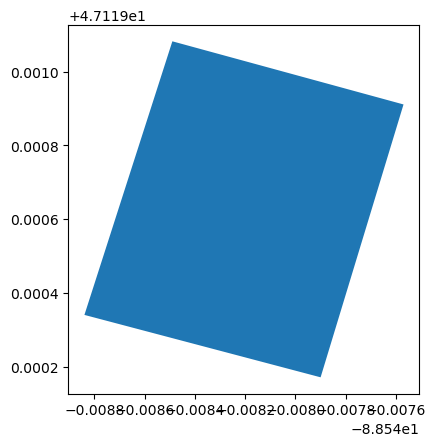

In [28]:
gdf.plot()

Naturally, you do not necessarily need to define the CRS separately after creating the GeoDataFrame, but you can actually provide the CRS information with the `crs` parameter when creating the dataset as follows:

In [29]:
# Create GeoDataFrame with one point and define the CRS
gdf = gpd.GeoDataFrame(data=gdf_data, crs="EPSG:4326")
gdf.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

As you can see, now the dataset contains the CRS information immediately after the dataset was created. You can pass the CRS information for the `crs` parameter in various formats (e.g. as EPSG number, Proj4 or WKT text) and `pyproj` / `geopandas` libraries try to automatically set the CRS information for the data.  

## Creating a GeoDataFrame from a text file

This is one of the most common real-world scenarios: you receive location data in a CSV or text file with latitude and longitude columns, and you need to convert it into a proper geospatial dataset.

One typical situation that you might encounter is that you receive coordinates data but they are stored in a delimited textfile (or an Excel file). You cannot directly read the data into GeoDataFrame, but it needs to be converted into geospatial data using the coordinate information. In such a case, we use pandas, geopandas, and shapely libraries to turn the data from a text file into a GeoDataFrame. 

To demonstrate this, we have some example data below that contains point coordinates of airports downloaded from [World Bank Data Catalog](https://datacatalog.worldbank.org/search/dataset/0038117/Global-Airports). The task of turning this data into a GeoDataFrame begins with reading the data with pandas into a DataFrame. Let's read the following columns from file:

In [30]:
import pandas as pd

airports = pd.read_csv(
    "data/airport_locations.csv",
    usecols=["ID", "Name", "Country", "Latitude", "Longitude"],
)
airports.head()

,ID,Name,Country,Latitude,Longitude
0,HEA,Herat,Afghanistan,34.206902,62.226700
1,JAA,Jalalabad,Afghanistan,34.400002,70.500000
2,KBL,Kabul International,Afghanistan,34.563900,69.213898
3,KDH,Kandahar International,Afghanistan,31.506901,65.847504
4,MZR,Mazar-e-Sharif,Afghanistan,36.704201,67.208298


In [31]:
type(airports)

pandas.core.frame.DataFrame

In [32]:
len(airports)

2173

As we can see, the data was read from a textfile into a pandas DataFrame. Our data covers over 2173 airports with attributes and coordinates in the `Latitude` and `Longitude` columns. We can use this coordinate information for turning the data into a GeoDataFrame and ultimately visualizing the data on a map. There is a handy function in geopandas called `.points_from_xy()` for generating an array of `Point` objects based on `x` and `y` coordinates. As usual, this function assumes that x-coordinates represent longitude and the y-coordinates represent latitude. 

The following code shows how we can create geometries for the airports based on these coordinates:

In [33]:
airports["geometry"] = gpd.points_from_xy(
    x=airports["Longitude"], y=airports["Latitude"]
)
airports.head()

,ID,Name,Country,Latitude,Longitude,geometry
0,HEA,Herat,Afghanistan,34.206902,62.226700,POINT (62.22670 34.20690)
1,JAA,Jalalabad,Afghanistan,34.400002,70.500000,POINT (70.50000 34.40000)
2,KBL,Kabul International,Afghanistan,34.563900,69.213898,POINT (69.21390 34.56390)
3,KDH,Kandahar International,Afghanistan,31.506901,65.847504,POINT (65.84750 31.50690)
4,MZR,Mazar-e-Sharif,Afghanistan,36.704201,67.208298,POINT (67.20830 36.70420)


In [34]:
type(airports)

pandas.core.frame.DataFrame

In [35]:
gdf_airports = gpd.GeoDataFrame(airports)
gdf_airports.head()

,ID,Name,Country,Latitude,Longitude,geometry
0,HEA,Herat,Afghanistan,34.206902,62.226700,POINT (62.22670 34.20690)
1,JAA,Jalalabad,Afghanistan,34.400002,70.500000,POINT (70.50000 34.40000)
2,KBL,Kabul International,Afghanistan,34.563900,69.213898,POINT (69.21390 34.56390)
3,KDH,Kandahar International,Afghanistan,31.506901,65.847504,POINT (65.84750 31.50690)
4,MZR,Mazar-e-Sharif,Afghanistan,36.704201,67.208298,POINT (67.20830 36.70420)


In [36]:
type(gdf_airports)

geopandas.geodataframe.GeoDataFrame

In summary, the GeoDataFrame was created with a couple of steps. 
- First, we created a new column called geometry into the DataFrame and used the `.points_from_xy()` function to turn the coordinates into shapely Point objects. At this stage, the data is still in a DataFrame format. 
- The second command converts the DataFrame into a GeoDataFrame.
- After these two steps, we have successfully turned the data into geospatial format and we can plot the data on a map:

## Summary

In this module, we learned the core GeoPandas workflow:

1. **Reading data**: `gpd.read_file()` loads geospatial files into GeoDataFrames
2. **Exploring data**: `.head()`, `.plot()`, `.geometry`, `.crs`
3. **Geometric operations**: `.area`, `.length` for computing properties
4. **Writing data**: `.to_file()` with different drivers (GeoPackage, Shapefile, FlatGeobuf)
5. **Creating GeoDataFrames**: From scratch with shapely geometries, or from CSV using `gpd.points_from_xy()`
6. **CRS management**: `.set_crs()` to assign, `.to_crs()` to reproject

**Key distinction**: `set_crs()` assigns CRS metadata (tells GeoPandas what coordinate system the data is in), while `to_crs()` actually reprojects the coordinates to a different system.

<Axes: >

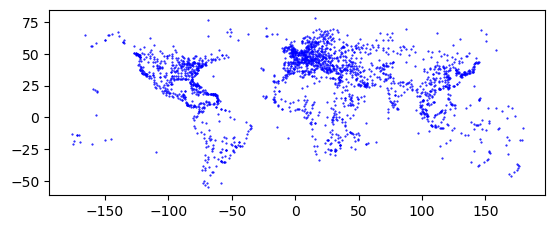

In [37]:
gdf_airports.plot(markersize=1,c='b',marker='.')